# Modifications Copyright (c) 2024 Advanced Micro Devices, Inc.
# Permission is hereby granted, free of charge, to any person obtaining a copy
# of this software and associated documentation files (the "Software"), to deal
# in the Software without restriction, including without limitation the rights
# to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
# copies of the Software, and to permit persons to whom the Software is
# furnished to do so, subject to the following conditions:
# The above copyright notice and this permission notice shall be included in
# all copies or substantial portions of the Software.
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
# IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
# FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
# AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER
# LIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,
# OUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN
# THE SOFTWARE.

# Preparation

In [1]:
!pip install pandas
!pip install matplotlib

# Import libraries
import pandas as pd

from Utils import *
%matplotlib inline

     |████████████████████████████████| 12.3 MB 7.3 MB/s eta 0:00:01
     |████████████████████████████████| 341 kB 7.3 MB/s eta 0:00:011
     |████████████████████████████████| 502 kB 137.6 MB/s eta 0:00:01
     |████████████████████████████████| 17.3 MB 139.8 MB/s eta 0:00:01
     |████████████████████████████████| 9.2 MB 6.6 MB/s eta 0:00:01
     |████████████████████████████████| 4.4 MB 146.3 MB/s eta 0:00:01
     |████████████████████████████████| 1.2 MB 87.0 MB/s eta 0:00:01
     |████████████████████████████████| 300 kB 137.1 MB/s eta 0:00:01
     |████████████████████████████████| 102 kB 139.3 MB/s eta 0:00:01
     |████████████████████████████████| 3.3 MB 141.1 MB/s eta 0:00:01


### Global Parameters

In [2]:
# Specify the data path
datafile = '../../../build/new_mi250_block.csv'

output_keys = ['Key','Benchmark', 'Label', 'Distribution', 'MatchingRate', 'Multiplicity', \
                'Occupancy', 'GPU Time (sec)', 'Elem/s (elem/sec)', 'INPUTSize']

### Import Data

In [3]:
# Read csv file
rawdf = pd.read_csv(datafile)

# Filter out skipped tests
perfdf = rawdf[rawdf["Key"] == rawdf["Value"]].reset_index(drop=True)


# Add labels
perfdf['Label'] = perfdf["Key"]
perfdf.loc[perfdf['Distribution'].notnull(), 'Label'] += "_" + perfdf['Distribution']
perfdf['Label'] += '_INPUT'+perfdf["INPUTSize"].astype(str)

# Trim data frame for visualization
perfdf = perfdf[output_keys]

# Visualization

### Visualization Parameters

In [4]:
# Get benchmark list
unique_bms = perfdf["Benchmark"].unique()
for it in unique_bms:
    print(it)

static_map_insert_uniform_multiplicity
static_map_insert_unique_occupancy
static_map_insert_gaussian_skew
static_map_find_unique_occupancy
static_map_find_unique_matching_rate
static_map_contains_unique_occupancy
static_map_contains_unique_matching_rate
static_map_erase_unique_occupancy
static_map_erase_unique_matching_rate


### `insert` performance by varying key muliplicities
<ul>
<li>100'000'000 insertions</li>
<li>UNIFORM distribution</li>
</ul>

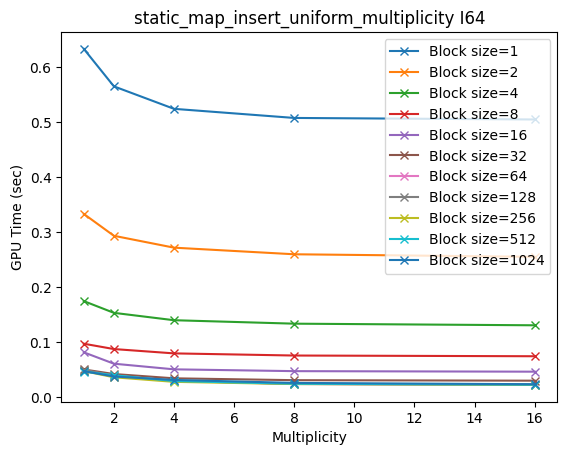

In [5]:
for bm in unique_bms:
    flag = "static_map_insert_uniform_multiplicity" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Multiplicity"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_insert_uniform_multiplicity I64")
          plt.xlabel("Multiplicity")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `insert` performance by varying occupancies
<ul>
<li>100'000'000 insertions</li>
<li>Fixed occupancy rate: 0.5</li>
</ul>

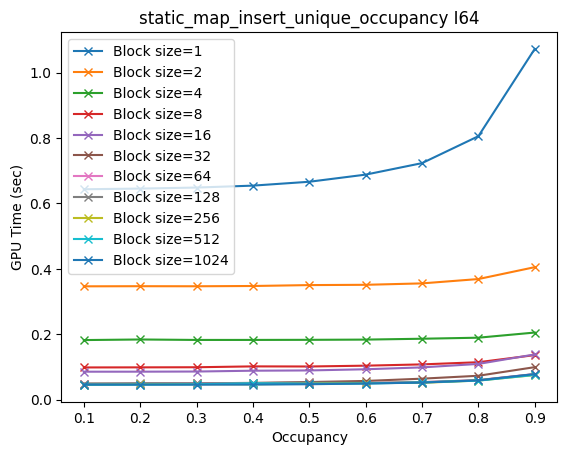

In [6]:
for bm in unique_bms:
    flag = "static_map_insert_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_insert_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `find` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
</ul>

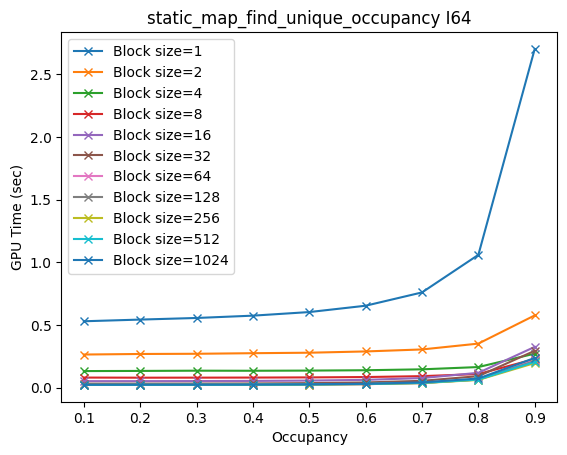

In [7]:
for bm in unique_bms:
    flag = "static_map_find_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_find_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `contains` performance by varying occupancies
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed matching rate: 0.5</li>
<li>Fixed occupancy: 0.5</li>
</ul>

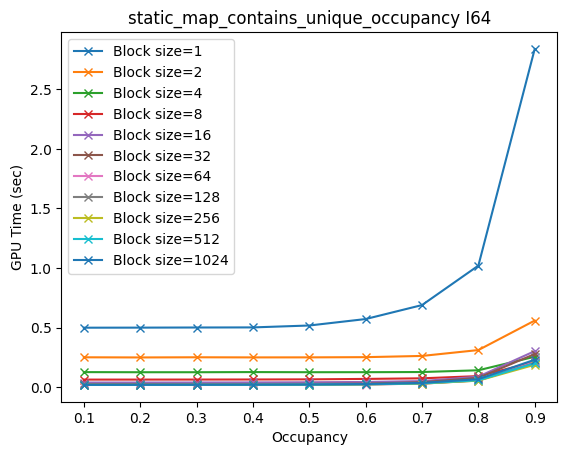

In [8]:
for bm in unique_bms:
    flag = "static_map_contains_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_contains_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `find` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
<li>Fixed matching rate: 0.5</li>
</ul>

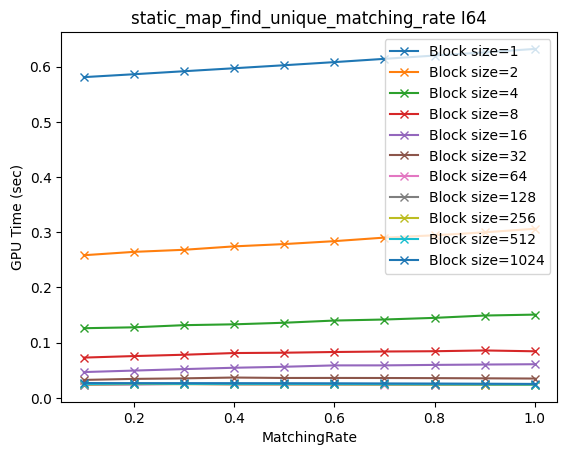

In [9]:
for bm in unique_bms:
    flag = "static_map_find_unique_matching_rate" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["MatchingRate"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_find_unique_matching_rate I64")
          plt.xlabel("MatchingRate")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `erase` performance by varying key muliplicities
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
</ul>

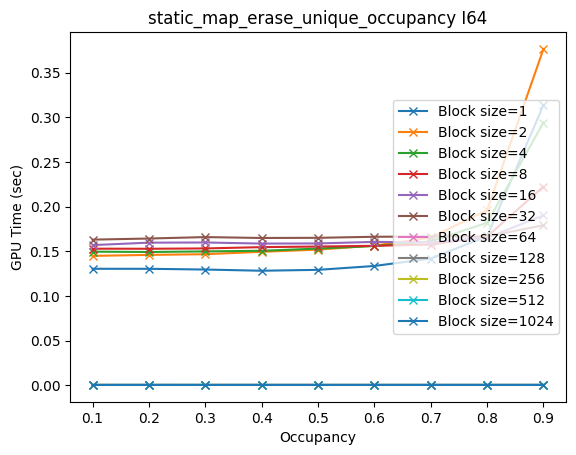

In [10]:
for bm in unique_bms:
    flag = "static_map_erase_unique_occupancy" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["Occupancy"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_erase_unique_occupancy I64")
          plt.xlabel("Occupancy")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `contains` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed occupancy: 0.5</li>
</ul>

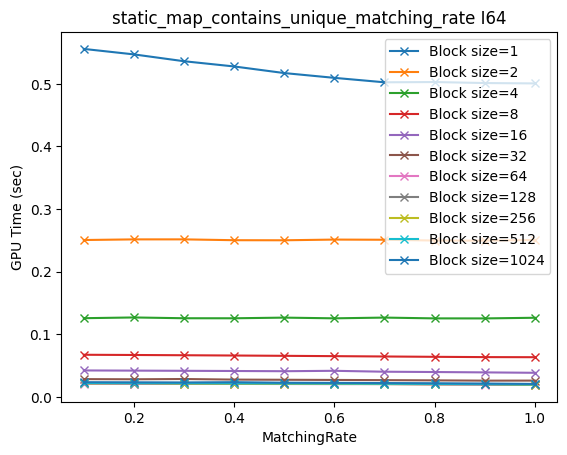

In [11]:
for bm in unique_bms:
    flag = "static_map_contains_unique_matching_rate" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["MatchingRate"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_contains_unique_matching_rate I64")
          plt.xlabel("MatchingRate")
          plt.ylabel("GPU Time (sec)")
          plt.legend()

### `erase` performance by varying matching rates
<ul>
<li>100'000'000 key/value pairs inserted</li>
<li>Fixed matching rate: 0.5</li>
</ul>

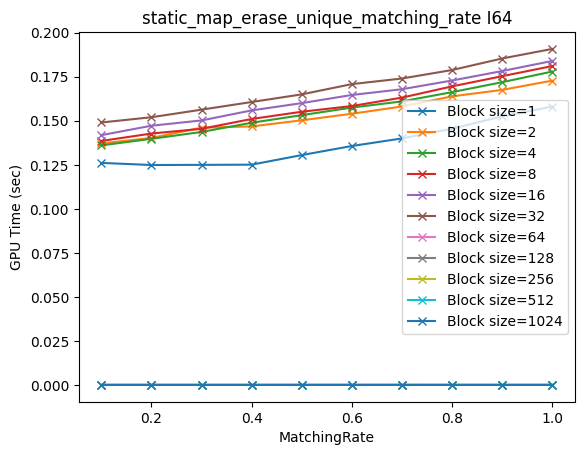

In [12]:
for bm in unique_bms:
    flag = "static_map_erase_unique_matching_rate" == bm
    
    if flag:
        tmpdf = perfdf[(perfdf["Benchmark"] == bm) & (perfdf["Key"]=="I64")]

        groups = tmpdf.groupby("INPUTSize")

        for group_name, group_data in groups:
          plt.plot(group_data["MatchingRate"], group_data["GPU Time (sec)"], label="Block size="+str(group_name), marker="x")

          plt.title("static_map_erase_unique_matching_rate I64")
          plt.xlabel("MatchingRate")
          plt.ylabel("GPU Time (sec)")
          plt.legend()